In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
import os
from scipy.stats import median_abs_deviation

DATA_PATH = os.path.join(os.getenv("AGED"), "CBMrepositoryData/perturbational_data/tahoe")

In [2]:
plate1 = sc.read(os.path.join(DATA_PATH, f"h5ad/plate1_filt_Vevo_Tahoe100M_WServicesFrom_ParseGigalab.h5ad"))

Sample likely refers to well, since there's 96 counts. Each well has a mosaic of 50 cell lines according to manuscript. Pseudobulking by sample, cell_line, drug should be appropriate.

In [9]:
plate1.obs[["sample"]].value_counts()

sample  
smp_1575    92840
smp_1590    90438
smp_1587    90237
smp_1581    90007
smp_1507    88750
            ...  
smp_1509      112
smp_1570       84
smp_1532       62
smp_1499       59
smp_1576       58
Name: count, Length: 96, dtype: int64

In [11]:
plate1.obs[["sample", "drugname_drugconc", "cell_line"]].value_counts()

sample    drugname_drugconc              cell_line
smp_1587  [('Anastrozole', 0.05, 'uM')]  CVCL_0546    6061
smp_1575  [('Gemcitabine', 0.05, 'uM')]  CVCL_0546    5979
                                         CVCL_0459    5754
smp_1587  [('Anastrozole', 0.05, 'uM')]  CVCL_0459    5640
smp_1589  [('DMSO_TF', 0.0, 'uM')]       CVCL_0546    5620
                                                      ... 
smp_1548  [('Sonidegib', 0.05, 'uM')]    CVCL_1531       1
                                         CVCL_1577       1
smp_1509  [('c-Kit-IN-1', 0.05, 'uM')]   CVCL_0399       1
                                         CVCL_0179       1
                                         CVCL_0152       1
Name: count, Length: 4666, dtype: int64

In [5]:
plate1.obs.pass_filter.value_counts()

pass_filter
full       5299930
minimal     181490
Name: count, dtype: int64

In [6]:
plate1.obs.columns

Index(['sample', 'gene_count', 'tscp_count', 'mread_count',
       'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE',
       'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter',
       'cell_name', 'plate'],
      dtype='object')

In [7]:
plate1.obs

,sample,gene_count,tscp_count,mread_count,drugname_drugconc,drug,cell_line,sublibrary,BARCODE,pcnt_mito,S_score,G2M_score,phase,pass_filter,cell_name,plate
BARCODE_SUB_LIB_ID,,,,,,,,,,,,,,,,
01_001_025-lib_841,smp_1495,1676,2441,2892,"[('Infigratinib', 0.05, 'uM')]",Infigratinib,CVCL_0131,lib_841,01_001_025,0.025399,-0.066667,-0.095055,G1,full,A-172,plate1
01_001_026-lib_841,smp_1495,1657,2454,2925,"[('Infigratinib', 0.05, 'uM')]",Infigratinib,CVCL_0480,lib_841,01_001_026,0.042787,0.128571,0.650549,G2M,full,PANC-1,plate1
01_001_048-lib_841,smp_1495,1749,2521,2963,"[('Infigratinib', 0.05, 'uM')]",Infigratinib,CVCL_0293,lib_841,01_001_048,0.056724,0.242857,0.308791,G2M,full,HEC-1-A,plate1
01_001_076-lib_841,smp_1495,834,1038,1258,"[('Infigratinib', 0.05, 'uM')]",Infigratinib,CVCL_0397,lib_841,01_001_076,0.066474,0.009524,0.245788,G2M,full,LS 180,plate1
01_001_088-lib_841,smp_1495,1275,1710,2006,"[('Infigratinib', 0.05, 'uM')]",Infigratinib,CVCL_1097,lib_841,01_001_088,0.028655,-0.100000,-0.085348,G1,full,C32,plate1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96_190_045-lib_912,smp_1590,1335,1900,2252,"[('DMSO_TF', 0.0, 'uM')]",DMSO_TF,CVCL_0546,lib_912,96_190_045,0.058421,-0.028936,0.615753,G2M,full,SW480,plate1
96_190_086-lib_912,smp_1590,2676,6496,7730,"[('DMSO_TF', 0.0, 'uM')]",DMSO_TF,CVCL_0152,lib_912,96_190_086,0.163639,-0.215881,-0.219544,G1,full,AsPC-1,plate1
96_191_055-lib_912,smp_1590,832,1254,1475,"[('DMSO_TF', 0.0, 'uM')]",DMSO_TF,CVCL_0152,lib_912,96_191_055,0.066188,-0.095694,-0.076463,G1,full,AsPC-1,plate1


In [8]:
plate1.var["mt"] = plate1.var_names.str.startswith("MT-")
plate1.var["ribo"] = plate1.var_names.str.startswith(("RPS", "RPL"))
plate1.var["hb"] = plate1.var_names.str.contains("^HB[^(P)]")

In [9]:
sc.pp.calculate_qc_metrics(
    plate1, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
plate1

AnnData object with n_obs × n_vars = 5481420 × 62710
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

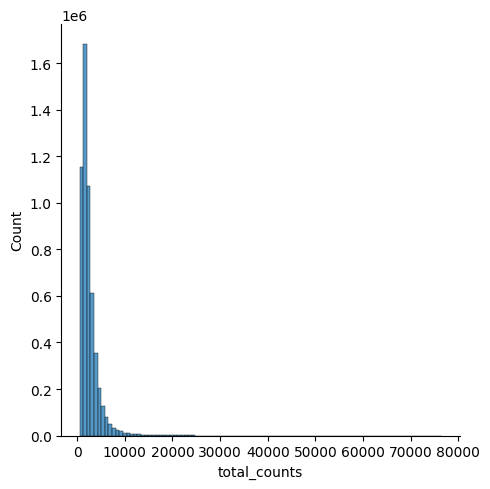

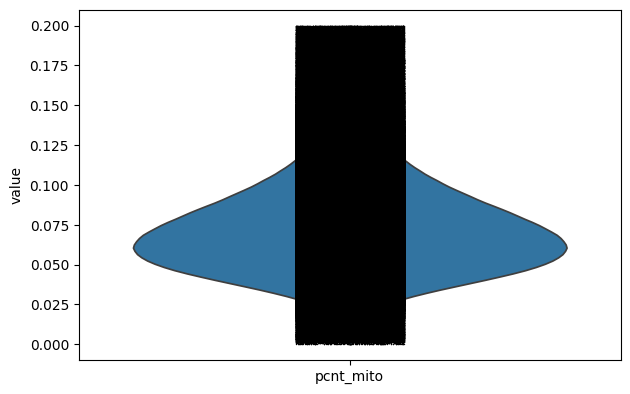

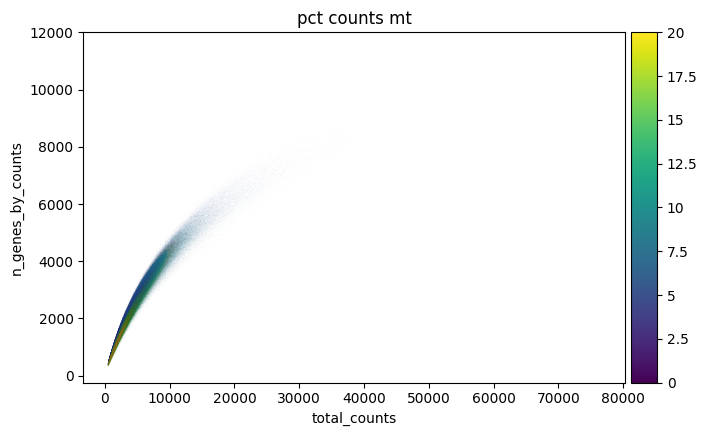

In [23]:
p1 = sns.displot(plate1.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(plate1, "pcnt_mito")
p3 = sc.pl.scatter(plate1, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
plate1_full_only = plate1[plate1.obs.pass_filter == "full",]

In [15]:
plate1_full_only.obs.gene_count.min()

np.int64(331)

In [18]:
plate1_full_only.obs.tscp_count.min()

np.int64(700)

In [19]:
plate1_full_only.obs.mread_count.min()

np.int64(785)

In [21]:
plate1_full_only.obs.pcnt_mito.max()

np.float32(0.2)

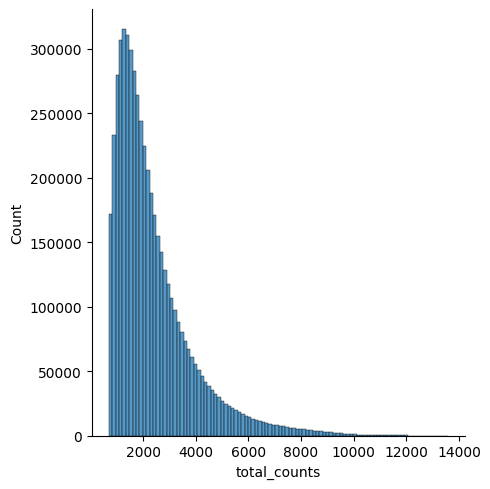

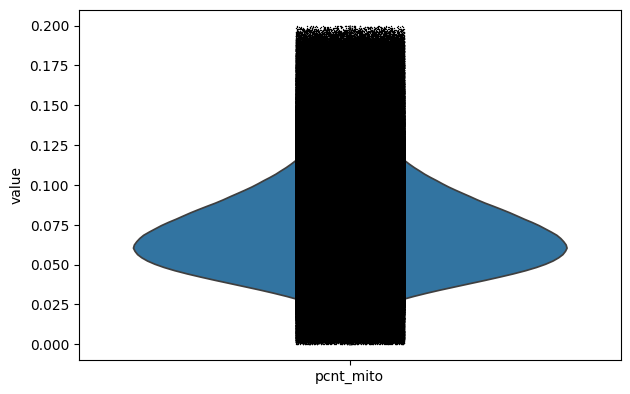

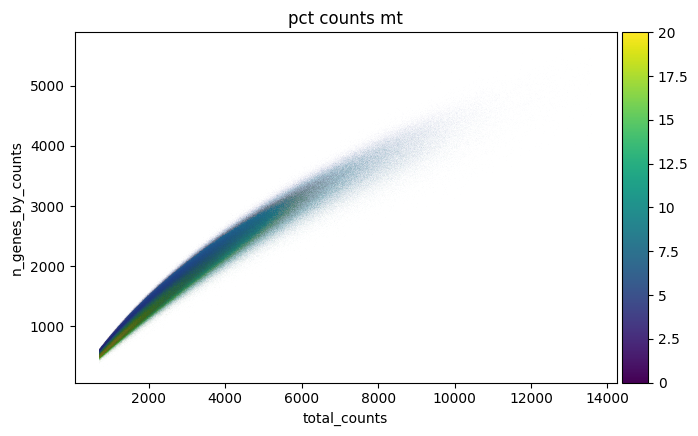

In [24]:
p1 = sns.displot(plate1_full_only.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(plate1_full_only, "pcnt_mito")
p3 = sc.pl.scatter(plate1_full_only, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

By visual inspection, subsetting to full filter column seems to fit Tahoe-100M's description of filtering: 'full' filtering requires cells to have at least 700 unique molecular identifiers (UMIs), less than 20% mitochondrial reads, a UMI z-score within ±3 to remove outliers in total counts, a mitochondrial percentage z-score within ±3 to remove outliers in mitochondrial content, and at least 250 genes detected.

In [ ]:
plate1_full_only.X